# MBG Smart Plate: Sistem Personalisasi Menu Gizi Berbasis Web untuk Mendukung Program Makan Bergizi Gratis

## Problem Discovery

**Latar Belakang:**
Program Makan Bergizi Gratis (MBG) menghadapi tantangan dalam personalisasi gizi. Saat ini, sistem cenderung memberikan menu generik tanpa mempertimbangkan kondisi fisik unik setiap siswa (stunting, gizi normal, atau overweight). Solusi yang ditawarkan adalah sistem personalisasi menu otomatis berdasarkan klasifikasi kondisi fisik berdasarkan status gizi siswa.

- Problem 1 (Fitur Gizi Signifikan): Apa saja parameter gizi yang paling berpengaruh/sebaiknya dijadikan patokan utama dalam menyusun rekomendasi menu personalisasi untuk siswa dengan status gizi berbeda?

- Problem 2 (Fitur Dominan): Variabel apa yang paling dominan mempengaruhi klasifikasi status gizi siswa?

- Problem 3 (Distribusi dan Prevalensi): Bagaimana distribusi status gizi siswa? Berapa persentase siswa yang memerlukan intervensi gizi prioritas (underweight dan overweight)? Kelompok usia mana yang diprioritaskan?

- Problem 4 (Rekomendasi Gizi): Berdasarkan data TKPI, bahan pangan apa saja yang memiliki kandungan gizi untuk menaikkan berat badan (kategori Underweight), mengoptimalkan berat badan (kategori normal), dan menurunkan berat badan (kategori Overweight)?

- Problem 5 (Implementasi A/B Testing): Apakah perubahan parameter gizi (peningkatan protein dan serat, serta penyesuaian kalori) pada menu rekomendasi berpengaruh signifikan terhadap perbaikan status gizi siswa (peningkatan berat badan untuk Underweight, penurunan untuk Overweight, dan maintenance untuk Normal) dibandingkan dengan menu standar MBG?

## Import Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
import joblib

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
plt.style.use('seaborn-v0_8-darkgrid')

## Data Wrangling

### Gathering Clean Data

In [4]:
# 1. Dataset Antropometri (BMI) Versi Clean
url_bmi_clean = 'https://docs.google.com/spreadsheets/d/1E-sdZCDNeM-6gXMc72xx4si10InHdp5DKERisgkzDSs/export?format=csv'
df_bmi_clean = pd.read_csv(url_bmi_clean)

print("\nDataset Antropometri")
print(f"Dataset memiliki {df_bmi_clean.shape[0]} baris dan {df_bmi_clean.shape[1]} kolom")
print("5 Baris Pertama:")
df_bmi_clean.head()


Dataset Antropometri
Dataset memiliki 24093 baris dan 6 kolom
5 Baris Pertama:


,Age,Gender,Gender_Encoded,Height,Weight,Status_Gizi
0,11,P,0,140.7,34.5,Normal
1,10,L,1,135.9,29.5,Normal
2,11,P,0,138.9,36.2,Overweight
3,10,P,0,131.9,28.5,Normal
4,6,L,1,117.0,17.3,Underweight


In [17]:
# 2. Dataset TKPI Versi Clean
url_tkpi_clean = 'https://docs.google.com/spreadsheets/d/1GZK2vG-8LBrHfDwedrBRZ6AnnrCYrgJwdaqJBgduFJc/export?format=csv'
df_tkpi_clean = pd.read_csv(url_tkpi_clean)

print("\nDataset TKPI")
print(f"Dataset memiliki {df_tkpi_clean.shape[0]} baris dan {df_tkpi_clean.shape[1]} kolom")
print("5 Baris Pertama:")
df_tkpi_clean.head()


Dataset TKPI
Dataset memiliki 908 baris dan 6 kolom
5 Baris Pertama:


,NAMA BAHAN,ENERGI (Kal),PROTEIN (g),LEMAK (g),KH (g),SERAT (g)
0,"Beras giling, mentah",357,8.4,1.7,77.1,0.2
1,"Beras giling var pelita, mentah",369,9.5,1.4,77.1,0.4
2,"Beras giling var rojolele, mentah",357,8.4,1.7,77.1,0.2
3,"Beras hitam, mentah",351,8.0,1.3,76.9,20.1
4,"Beras jagung kuning, kering, mentah",358,5.5,0.1,82.7,10.0


### Assessing Clean Data (Pengecekan Anomali Data)

In [19]:
# 1. Dataset Antropometri (BMI) Versi Clean
print("\nNama Kolom Dataset BMI:")
print(df_bmi_clean.columns.tolist())

## Informasi Dataset
print("\nInformasi Dataset:")
df_bmi_clean.info()

## Cek Missing Values
print("\nCek Missing Values:")
print(df_bmi_clean.isnull().sum())
print(f"\nTotal Missing Values: {df_bmi_clean.isnull().sum().sum()}")

## Cek Duplikasi
print("\nCek Duplikasi:")
print(f"Jumlah duplikat: {df_bmi_clean.duplicated().sum()}")

## Statistik Deskriptif (TANPA BMI karena belum dibuat)
print("\nStatistik Deskriptif:")
# Hanya kolom yang tersedia
numeric_cols = ['Age', 'Height', 'Weight']
# Cek apakah kolom ada sebelum dipanggil
available_numeric = [col for col in numeric_cols if col in df_bmi_clean.columns]
print(df_bmi_clean[available_numeric].describe())

## Unique Values Kolom Kategorikal
print("\nUnique Values Kolom Kategorikal:")
if 'Gender' in df_bmi_clean.columns:
    print(f"Jenis Kelamin (Gender): {df_bmi_clean['Gender'].unique()}")
if 'Status_Gizi' in df_bmi_clean.columns:
    print(f"Label Status Gizi (Status_Gizi): {df_bmi_clean['Status_Gizi'].unique()}")

## Deteksi Data Invalid
print("\nDeteksi Data Invalid:")

### Invalid di kolom 'Age' (usia tidak wajar)
if 'Age' in df_bmi_clean.columns:
    invalid_age = df_bmi_clean[(df_bmi_clean['Age'] < 5) | (df_bmi_clean['Age'] > 16)].shape[0]
    print(f"  - Invalid Age (<5 atau >16 tahun): {invalid_age} baris")

### Invalid di kolom 'Height' (di luar rentang 100-165 cm)
if 'Height' in df_bmi_clean.columns:
    invalid_height = df_bmi_clean[(df_bmi_clean['Height'] < 100) | (df_bmi_clean['Height'] > 165)].shape[0]
    print(f"  - Invalid Height (<100 atau >165 cm): {invalid_height} baris")

### Invalid di kolom 'Weight' (di luar rentang 15-65 kg)
if 'Weight' in df_bmi_clean.columns:
    invalid_weight = df_bmi_clean[(df_bmi_clean['Weight'] < 15) | (df_bmi_clean['Weight'] > 65)].shape[0]
    print(f"  - Invalid Weight (<15 atau >65 kg): {invalid_weight} baris")

### Invalid di kolom 'Gender' (bukan 'Laki-Laki' atau 'Perempuan')
if 'Gender' in df_bmi_clean.columns:
    invalid_gender = df_bmi_clean[~df_bmi_clean['Gender'].isin(['L', 'P']) & df_bmi_clean['Gender'].notna()].shape[0]
    print(f"  - Invalid Gender (bukan Pria/Wanita): {invalid_gender} baris")

### Invalid di kolom 'Status_Gizi' (bukan 4 kategori valid)
if 'Status_Gizi' in df_bmi_clean.columns:
    valid_labels = ['Underweight', 'Normal', 'Overweight', 'Obesity']
    invalid_status = df_bmi_clean[~df_bmi_clean['Status_Gizi'].isin(valid_labels) & df_bmi_clean['Status_Gizi'].notna()].shape[0]
    print(f"  - Invalid Status_Gizi: {invalid_status} baris")

## Deteksi Inkonsistensi (casing/spacing)
print("\nDeteksi Inkonsistensi:")

if 'Gender' in df_bmi_clean.columns:
    gender_inconsistent = df_bmi_clean[df_bmi_clean['Gender'].astype(str).str.contains('^[a-z]', na=False)].shape[0]
    print(f"  - Inkonsistensi casing Gender (huruf kecil): {gender_inconsistent} baris")
    
    gender_spasi = df_bmi_clean[df_bmi_clean['Gender'].astype(str).str.contains('^\s|\s$', na=False)].shape[0]
    print(f"  - Spasi berlebih di Gender: {gender_spasi} baris")

if 'Status_Gizi' in df_bmi_clean.columns:
    status_inconsistent = df_bmi_clean[df_bmi_clean['Status_Gizi'].astype(str).str.contains('^[a-z]', na=False) & df_bmi_clean['Status_Gizi'].notna()].shape[0]
    print(f"  - Inkonsistensi casing Status_Gizi (huruf kecil): {status_inconsistent} baris")
    
    status_spasi = df_bmi_clean[df_bmi_clean['Status_Gizi'].astype(str).str.contains('^\s|\s$', na=False)].shape[0]
    print(f"  - Spasi berlebih di Status_Gizi: {status_spasi} baris")

## Ringkasan Anomali Data
total_issues = df_bmi_clean.isnull().sum().sum() + df_bmi_clean.duplicated().sum()

if 'Age' in df_bmi_clean.columns:
    total_issues += invalid_age
if 'Height' in df_bmi_clean.columns:
    total_issues += invalid_height
if 'Weight' in df_bmi_clean.columns:
    total_issues += invalid_weight
if 'Gender' in df_bmi_clean.columns:
    total_issues += invalid_gender + gender_inconsistent + gender_spasi
if 'Status_Gizi' in df_bmi_clean.columns:
    total_issues += invalid_status + status_inconsistent + status_spasi

print(f"Total Anomali Terdeteksi: {total_issues}")



Nama Kolom Dataset BMI:
['Age', 'Gender', 'Gender_Encoded', 'Height', 'Weight', 'Status_Gizi']

Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 24093 entries, 0 to 24092
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             24093 non-null  int64  
 1   Gender          24093 non-null  str    
 2   Gender_Encoded  24093 non-null  int64  
 3   Height          24093 non-null  float64
 4   Weight          24093 non-null  float64
 5   Status_Gizi     24093 non-null  str    
dtypes: float64(2), int64(2), str(2)
memory usage: 1.3 MB

Cek Missing Values:
Age               0
Gender            0
Gender_Encoded    0
Height            0
Weight            0
Status_Gizi       0
dtype: int64

Total Missing Values: 0

Cek Duplikasi:
Jumlah duplikat: 0

Statistik Deskriptif:
                Age        Height        Weight
count  24093.000000  24093.000000  24093.000000
mean       9.254306    130.478529   

In [20]:
# 2. Dataset TKPI Versi Clean
print("\nNama Kolom Dataset TKPI:")
print(df_tkpi_clean.columns.tolist())

## Informasi Dataset
print("\nInformasi Dataset:")
df_tkpi_clean.info()

print("\nMissing Values Dataset TKPI:")
print(df_tkpi_clean.isnull().sum())

## Ringkasan Anomali Data
print("\nRingkasan Anomali Data:")
total_issues = (df_tkpi_clean.isnull().sum().sum())
print(f"Total Anomali Terdeteksi: {total_issues}")


Nama Kolom Dataset TKPI:
['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)', 'SERAT (g)']

Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   NAMA BAHAN    908 non-null    str    
 1   ENERGI (Kal)  908 non-null    int64  
 2   PROTEIN (g)   908 non-null    float64
 3   LEMAK (g)     908 non-null    float64
 4   KH (g)        908 non-null    float64
 5   SERAT (g)     908 non-null    float64
dtypes: float64(4), int64(1), str(1)
memory usage: 58.8 KB

Missing Values Dataset TKPI:
NAMA BAHAN      0
ENERGI (Kal)    0
PROTEIN (g)     0
LEMAK (g)       0
KH (g)          0
SERAT (g)       0
dtype: int64

Ringkasan Anomali Data:
Total Anomali Terdeteksi: 0


**Insight Clean Dataset:**
- Dataset Antropometri memiliki 24093 baris dan 6 kolom setelah tahap cleaning data.
- Nama Kolom Dataset BMI antara lain: 'Age', 'Gender', 'Gender_Encoded', 'Height', 'Weight', dan 'Status_Gizi'.
- Dataset TKPI memiliki 908 baris dan 6 kolom setelah tahap cleaning data.
- Nama Kolom Dataset TKPI antara lain: 'NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)', dan 'SERAT (g)'.

## Exploratory Data Analysis (EDA)

### Data Dictionary

In [22]:
# Simpan data clean untuk dashboard
df_bmi_clean.to_csv('df_bmi_clean.csv', index=False)
print("✅ Data clean disimpan sebagai 'df_bmi_clean.csv'")

# Cek shape
print(f"Shape data clean: {df_bmi_clean.shape}")
print(f"Distribusi Status Gizi:\n{df_bmi_clean['Status_Gizi'].value_counts()}")

print(df_bmi_clean.head())

# Data Dictionary untuk Dataset BMI
data_dict_bmi = {
    'Kolom': ['Age', 'Gender', 'Height', 'Weight', 'BMI', 'Status_Gizi', 'Gender_Encoded', 'Age_Group'],
    'Tipe Data': ['Integer', 'Kategorikal', 'Float', 'Float', 'Float', 'Kategorikal', 'Integer', 'Kategorikal'],
    'Deskripsi': [
        'Usia siswa dalam tahun',
        'Jenis kelamin siswa',
        'Tinggi badan siswa',
        'Berat badan siswa',
        'Indeks Massa Tubuh (hasil perhitungan)',
        'Klasifikasi status gizi berdasarkan BMI',
        'Encoding numerik dari jenis kelamin',
        'Pengelompokan usia berdasarkan quantile'
    ],
    'Rentang/Satuan': [
        '6-12 tahun',
        'Laki-Laki / Perempuan',
        '100-165 cm',
        '15-65 kg',
        '12-30 kg/m²',
        'Underweight / Normal / Overweight / Obesity',
        '1=Laki-Laki (L), 0=Perempuan (P)',
        'Q1(6-7thn) / Q2(8-9thn) / Q3(10-11thn) / Q4(12thn)'
    ]
}

df_dict_bmi = pd.DataFrame(data_dict_bmi)
print("\nDATA DICTIONARY - DATASET BMI")
print(df_dict_bmi.to_string(index=False))

# Data Dictionary untuk Dataset TKPI
data_dict_tkpi = {
    'Kolom': ['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)', 'SERAT (g)'],
    'Tipe Data': ['String', 'Float', 'Float', 'Float', 'Float', 'Float'],
    'Deskripsi': [
        'Nama bahan pangan mentah',
        'Kandungan energi total',
        'Kandungan protein',
        'Kandungan lemak',
        'Kandungan karbohidrat',
        'Kandungan serat pangan'
    ],
    'Rentang/Satuan': [
        'Beragam',
        '0-900+ Kalori',
        '0-35+ gram',
        '0-100+ gram',
        '0-90+ gram',
        '0-30+ gram'
    ]
}

df_dict_tkpi = pd.DataFrame(data_dict_tkpi)
print("\nDATA DICTIONARY - DATASET TKPI")
print(df_dict_tkpi.to_string(index=False))

import os
downloads_path = r"C:\Users\LENOVO\Downloads"

# Simpan ke folder Downloads
df_dict_bmi.to_csv(os.path.join(downloads_path, 'data_dictionary_bmi.csv'), index=False)
df_dict_tkpi.to_csv(os.path.join(downloads_path, 'data_dictionary_tkpi.csv'), index=False)

print(f"✅ File disimpan di: {downloads_path}")


✅ Data clean disimpan sebagai 'df_bmi_clean.csv'
Shape data clean: (24093, 6)
Distribusi Status Gizi:
Status_Gizi
Normal         14689
Overweight      7326
Underweight     1990
Obesity           88
Name: count, dtype: int64
   Age Gender  Gender_Encoded  Height  Weight  Status_Gizi
0   11      P               0   140.7    34.5       Normal
1   10      L               1   135.9    29.5       Normal
2   11      P               0   138.9    36.2   Overweight
3   10      P               0   131.9    28.5       Normal
4    6      L               1   117.0    17.3  Underweight

DATA DICTIONARY - DATASET BMI
         Kolom   Tipe Data                               Deskripsi                                     Rentang/Satuan
           Age     Integer                  Usia siswa dalam tahun                                         6-12 tahun
        Gender Kategorikal                     Jenis kelamin siswa                              Laki-Laki / Perempuan
        Height       Float           

### Feature Engineering (Kolom BMI)

In [25]:
# Hitung BMI dari Height dan Weight
## Rumus BMI = Weight (kg) / (Height (m))^2
df_bmi_clean['BMI'] = round(df_bmi_clean['Weight'] / ((df_bmi_clean['Height'] / 100) ** 2), 2)

print(f"Kolom BMI berhasil dibuat")
print(f"Rentang BMI: {df_bmi_clean['BMI'].min():.2f} - {df_bmi_clean['BMI'].max():.2f}")
print(f"Rata-rata BMI: {df_bmi_clean['BMI'].mean():.2f}")

cols = df_bmi_clean.columns.tolist()

## Cari posisi kolom 'Status_Gizi' (bukan 'label')
if 'Status_Gizi' in cols:
    target_col = 'Status_Gizi'
elif 'label' in cols:
    target_col = 'label'
else:
    target_col = None
    print("⚠️ Kolom 'Status_Gizi' atau 'label' tidak ditemukan!")

if target_col:
    label_idx = cols.index(target_col)
    
    # Hapus BMI dari daftar kolom jika sudah ada (untuk menghindari duplikasi)
    if 'BMI' in cols:
        cols.remove('BMI')
    
    # Masukkan BMI sebelum kolom target
    new_cols = cols[:label_idx] + ['BMI'] + cols[label_idx:]
    df_bmi_clean = df_bmi_clean[new_cols]

print("\nUrutan kolom setelah ditambah BMI:")
print(df_bmi_clean.columns.tolist())

print("\nSample data (5 baris pertama):")
df_bmi_clean.head()

Kolom BMI berhasil dibuat
Rentang BMI: 11.90 - 23.88
Rata-rata BMI: 16.93

Urutan kolom setelah ditambah BMI:
['Age', 'Gender', 'Gender_Encoded', 'Height', 'Weight', 'BMI', 'Status_Gizi']

Sample data (5 baris pertama):


,Age,Gender,Gender_Encoded,Height,Weight,BMI,Status_Gizi
0,11,P,0,140.7,34.5,17.43,Normal
1,10,L,1,135.9,29.5,15.97,Normal
2,11,P,0,138.9,36.2,18.76,Overweight
3,10,P,0,131.9,28.5,16.38,Normal
4,6,L,1,117.0,17.3,12.64,Underweight


### EDA Kolom Umur (Age)

  - Rata-rata umur: 9.25 tahun
  - Median umur: 9 tahun
  - Umur termuda: 6 tahun
  - Umur tertua: 12 tahun
  - Standar deviasi: 1.92


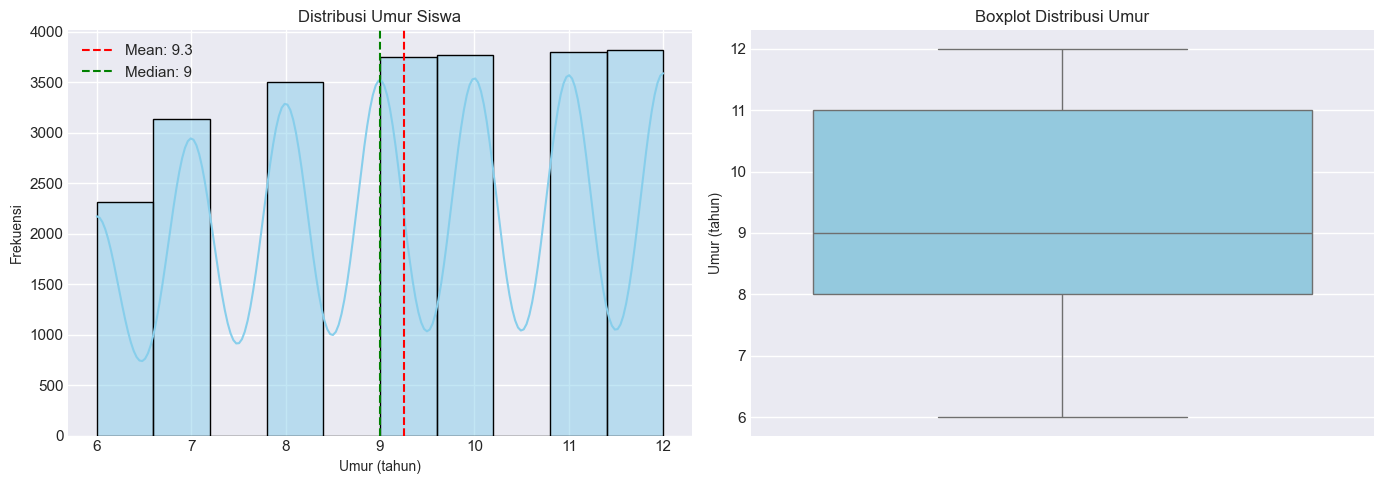

In [26]:
print(f"  - Rata-rata umur: {df_bmi_clean['Age'].mean():.2f} tahun")
print(f"  - Median umur: {df_bmi_clean['Age'].median():.0f} tahun")
print(f"  - Umur termuda: {df_bmi_clean['Age'].min():.0f} tahun")
print(f"  - Umur tertua: {df_bmi_clean['Age'].max():.0f} tahun")
print(f"  - Standar deviasi: {df_bmi_clean['Age'].std():.2f}")

# Histogram Umur
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram dengan KDE
sns.histplot(df_bmi_clean['Age'], bins=10, kde=True, color='skyblue', ax=axes[0], edgecolor='black')
axes[0].set_title('Distribusi Umur Siswa', fontsize=12)
axes[0].set_xlabel('Umur (tahun)', fontsize=10)
axes[0].set_ylabel('Frekuensi', fontsize=10)
axes[0].axvline(df_bmi_clean['Age'].mean(), color='red', linestyle='--', label=f"Mean: {df_bmi_clean['Age'].mean():.1f}")
axes[0].axvline(df_bmi_clean['Age'].median(), color='green', linestyle='--', label=f"Median: {df_bmi_clean['Age'].median():.0f}")
axes[0].legend()

# Boxplot Umur
sns.boxplot(y=df_bmi_clean['Age'], ax=axes[1], color='skyblue')
axes[1].set_title('Boxplot Distribusi Umur', fontsize=12)
axes[1].set_ylabel('Umur (tahun)', fontsize=10)

plt.tight_layout()
plt.show()

### EDA Kolom Jenis Kelamin (Gender)

  - Laki-laki (L): 12025 siswa (49.9%)
  - Perempuan (P): 12068 siswa (50.1%)


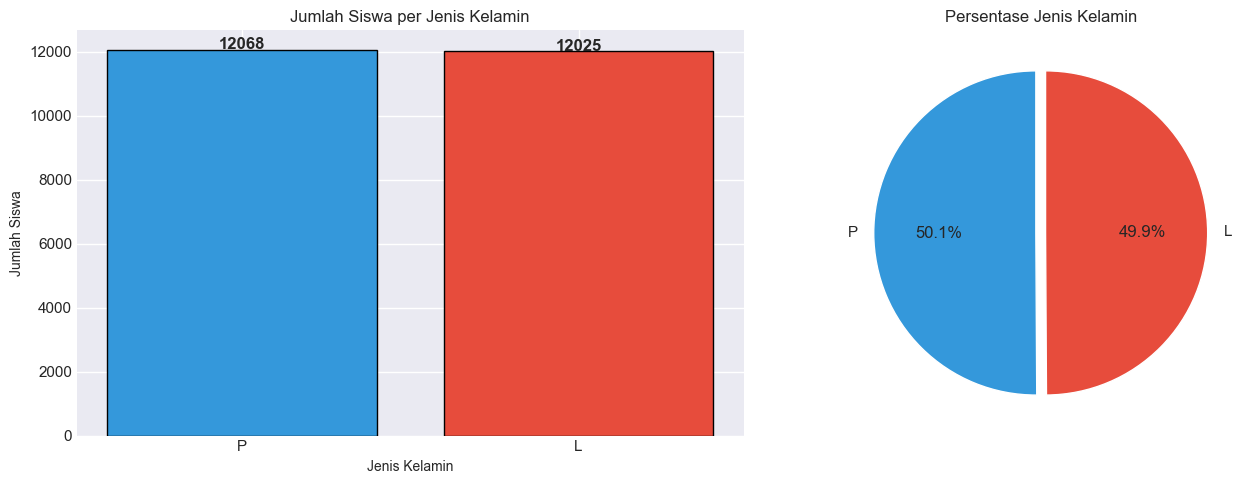

In [27]:
gender_counts = df_bmi_clean['Gender'].value_counts()
gender_pct = df_bmi_clean['Gender'].value_counts(normalize=True) * 100
print(f"  - Laki-laki (L): {gender_counts.get('L', 0)} siswa ({gender_pct.get('L', 0):.1f}%)")
print(f"  - Perempuan (P): {gender_counts.get('P', 0)} siswa ({gender_pct.get('P', 0):.1f}%)")

# Visualisasi Gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors_gender = ['#3498DB', '#E74C3C']
bars = axes[0].bar(gender_counts.index, gender_counts.values, color=colors_gender, edgecolor='black')
axes[0].set_title('Jumlah Siswa per Jenis Kelamin', fontsize=12)
axes[0].set_xlabel('Jenis Kelamin', fontsize=10)
axes[0].set_ylabel('Jumlah Siswa', fontsize=10)
for bar, count in zip(bars, gender_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', 
            colors=colors_gender, startangle=90, explode=(0.03, 0.03))
axes[1].set_title('Persentase Jenis Kelamin', fontsize=12)

plt.tight_layout()
plt.show()

### EDA Kolom Tinggi Badan (Height)

  - Rata-rata tinggi: 130.48 cm
  - Median tinggi: 129.90 cm
  - Tinggi minimum: 110.00 cm
  - Tinggi maksimum: 152.00 cm
  - Standar deviasi: 10.91 cm


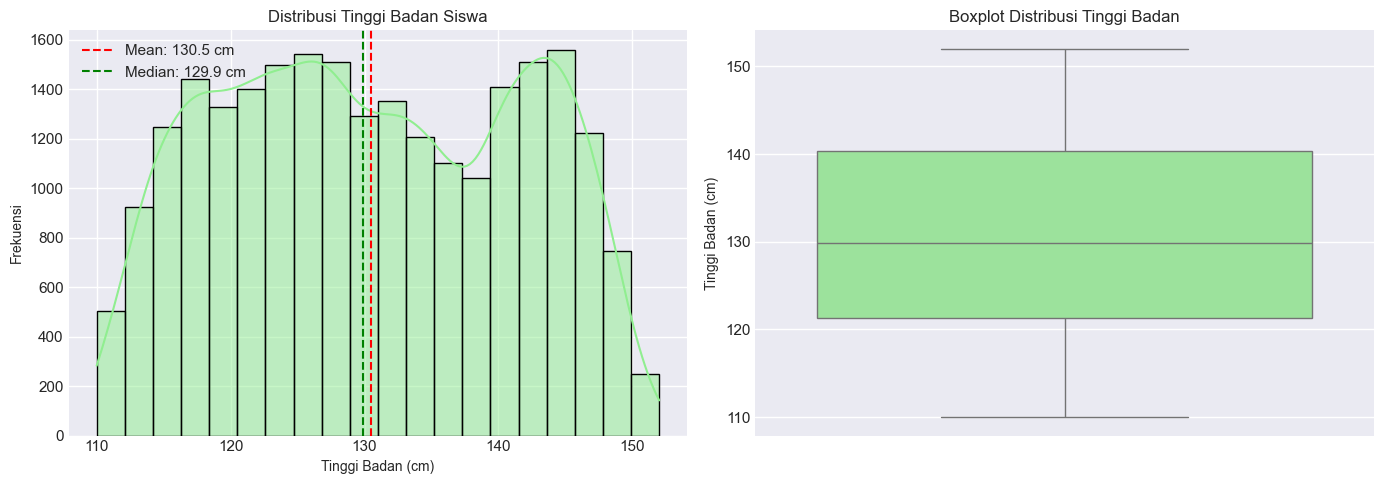

In [28]:
print(f"  - Rata-rata tinggi: {df_bmi_clean['Height'].mean():.2f} cm")
print(f"  - Median tinggi: {df_bmi_clean['Height'].median():.2f} cm")
print(f"  - Tinggi minimum: {df_bmi_clean['Height'].min():.2f} cm")
print(f"  - Tinggi maksimum: {df_bmi_clean['Height'].max():.2f} cm")
print(f"  - Standar deviasi: {df_bmi_clean['Height'].std():.2f} cm")

# Histogram Tinggi Badan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram dengan KDE
sns.histplot(df_bmi_clean['Height'], bins=20, kde=True, color='lightgreen', ax=axes[0], edgecolor='black')
axes[0].set_title('Distribusi Tinggi Badan Siswa', fontsize=12)
axes[0].set_xlabel('Tinggi Badan (cm)', fontsize=10)
axes[0].set_ylabel('Frekuensi', fontsize=10)
axes[0].axvline(df_bmi_clean['Height'].mean(), color='red', linestyle='--', label=f"Mean: {df_bmi_clean['Height'].mean():.1f} cm")
axes[0].axvline(df_bmi_clean['Height'].median(), color='green', linestyle='--', label=f"Median: {df_bmi_clean['Height'].median():.1f} cm")
axes[0].legend()

# Boxplot Tinggi Badan
sns.boxplot(y=df_bmi_clean['Height'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot Distribusi Tinggi Badan', fontsize=12)
axes[1].set_ylabel('Tinggi Badan (cm)', fontsize=10)

plt.tight_layout()
plt.show()

### EDA Kolom Berat Badan (Weight)

  - Rata-rata berat: 29.29 kg
  - Median berat: 29.00 kg
  - Berat minimum: 17.00 kg
  - Berat maksimum: 48.00 kg
  - Standar deviasi: 7.06 kg


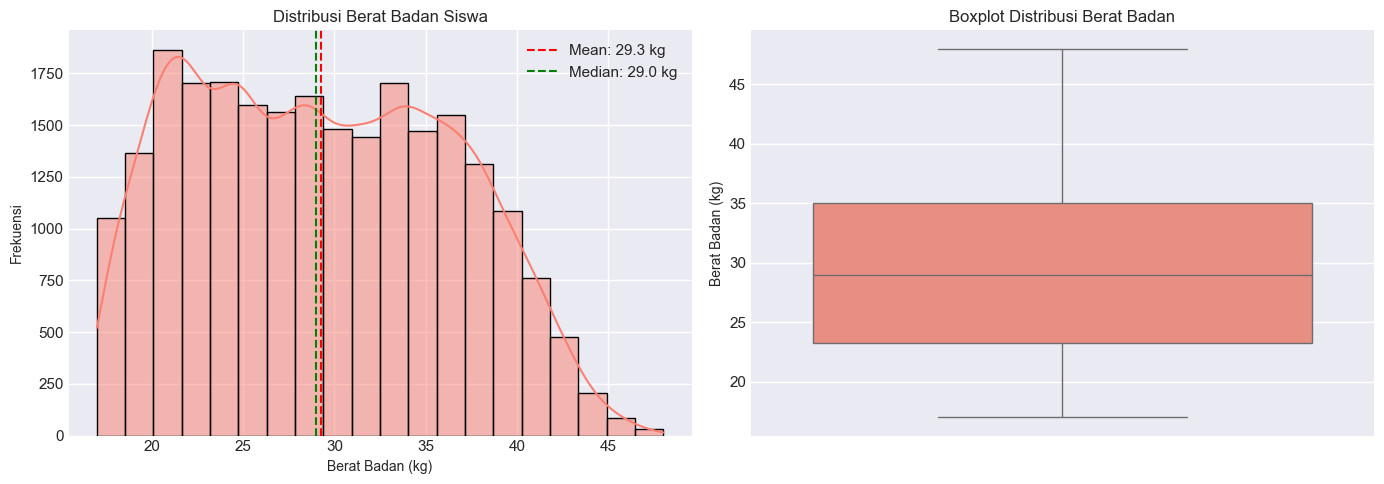

In [29]:
print(f"  - Rata-rata berat: {df_bmi_clean['Weight'].mean():.2f} kg")
print(f"  - Median berat: {df_bmi_clean['Weight'].median():.2f} kg")
print(f"  - Berat minimum: {df_bmi_clean['Weight'].min():.2f} kg")
print(f"  - Berat maksimum: {df_bmi_clean['Weight'].max():.2f} kg")
print(f"  - Standar deviasi: {df_bmi_clean['Weight'].std():.2f} kg")

# Histogram Berat Badan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram dengan KDE
sns.histplot(df_bmi_clean['Weight'], bins=20, kde=True, color='salmon', ax=axes[0], edgecolor='black')
axes[0].set_title('Distribusi Berat Badan Siswa', fontsize=12)
axes[0].set_xlabel('Berat Badan (kg)', fontsize=10)
axes[0].set_ylabel('Frekuensi', fontsize=10)
axes[0].axvline(df_bmi_clean['Weight'].mean(), color='red', linestyle='--', label=f"Mean: {df_bmi_clean['Weight'].mean():.1f} kg")
axes[0].axvline(df_bmi_clean['Weight'].median(), color='green', linestyle='--', label=f"Median: {df_bmi_clean['Weight'].median():.1f} kg")
axes[0].legend()

# Boxplot Berat Badan
sns.boxplot(y=df_bmi_clean['Weight'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot Distribusi Berat Badan', fontsize=12)
axes[1].set_ylabel('Berat Badan (kg)', fontsize=10)

plt.tight_layout()
plt.show()



### EDA Kolom BMI

  - Rata-rata BMI: 16.93 kg/m²
  - Median BMI: 16.96 kg/m²
  - BMI minimum: 11.90 kg/m²
  - BMI maksimum: 23.88 kg/m²
  - Standar deviasi: 2.02
Distribusi BMI berdasarkan data aktual:
               min    max   mean
Status_Gizi                     
Normal       13.17  21.05  16.24
Obesity      22.00  23.88  22.41
Overweight   17.96  22.02  19.23
Underweight  11.90  14.04  13.36

Batas kategori berdasarkan data:
  - Normal: 13.2 - 21.1
  - Overweight: ≥ 18.0
  - Obesity: ≥ 22.0


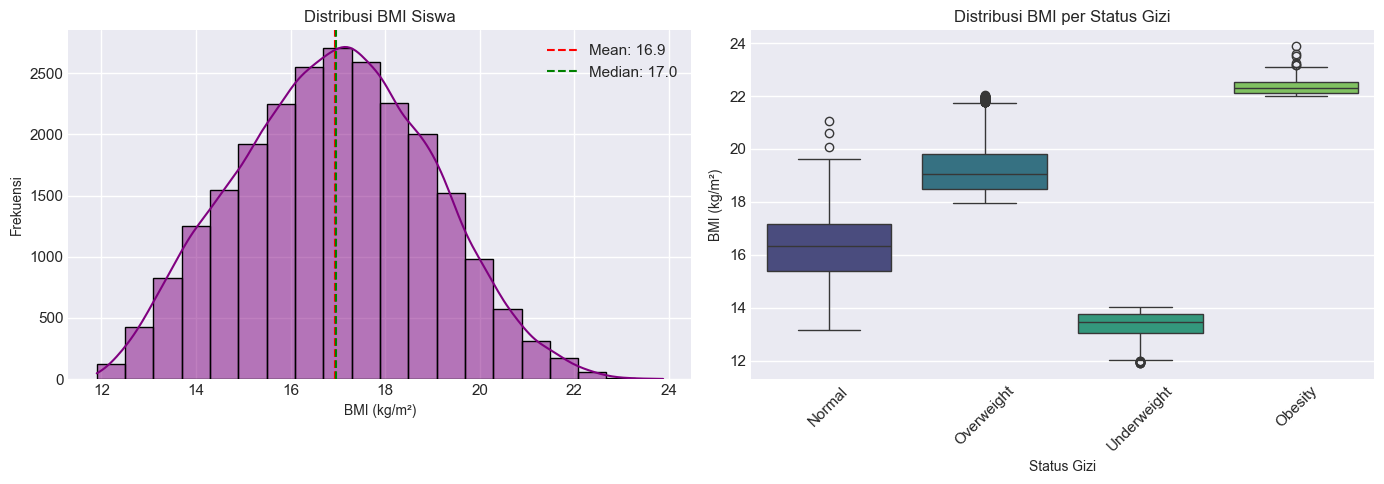

  - Underweight: 624 siswa (2.6%)
  - Normal: 23024 siswa (95.6%)
  - Overweight: 354 siswa (1.5%)
  - Obesity: 91 siswa (0.4%)


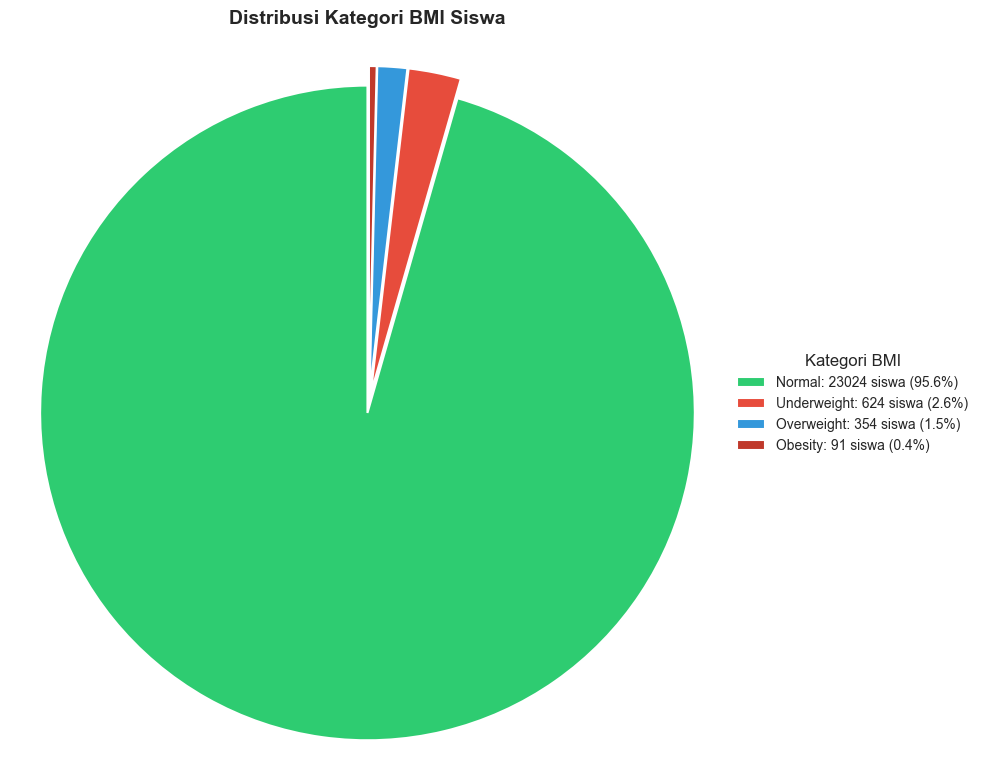

In [35]:
print(f"  - Rata-rata BMI: {df_bmi_clean['BMI'].mean():.2f} kg/m²")
print(f"  - Median BMI: {df_bmi_clean['BMI'].median():.2f} kg/m²")
print(f"  - BMI minimum: {df_bmi_clean['BMI'].min():.2f} kg/m²")
print(f"  - BMI maksimum: {df_bmi_clean['BMI'].max():.2f} kg/m²")
print(f"  - Standar deviasi: {df_bmi_clean['BMI'].std():.2f}")

# Hitung statistik BMI per status gizi dari data aktual
bmi_stats = df_bmi_clean.groupby('Status_Gizi')['BMI'].agg(['min', 'max', 'mean']).round(2)
print("Distribusi BMI berdasarkan data aktual:")
print(bmi_stats)

# Ambil batas dari data aktual
batas_normal_min = bmi_stats.loc['Normal', 'min']  # sekitar 16.5
batas_normal_max = bmi_stats.loc['Normal', 'max']  # sekitar 20
batas_overweight_min = bmi_stats.loc['Overweight', 'min']  # sekitar 20
batas_obesity_min = bmi_stats.loc['Obesity', 'min'] if 'Obesity' in bmi_stats.index else 23

print(f"\nBatas kategori berdasarkan data:")
print(f"  - Normal: {batas_normal_min:.1f} - {batas_normal_max:.1f}")
print(f"  - Overweight: ≥ {batas_overweight_min:.1f}")
print(f"  - Obesity: ≥ {batas_obesity_min:.1f}")

# Fungsi kategori BMI berdasarkan data aktual
def kategori_bmi_aktual(bmi):
    if bmi < batas_normal_min:  
        return 'Underweight'
    elif bmi < batas_normal_max:  
        return 'Normal'
    elif bmi < batas_obesity_min: 
        return 'Overweight'
    else:
        return 'Obesity'

# Terapkan fungsi
df_bmi_clean['BMI_Kategori'] = df_bmi_clean['BMI'].apply(kategori_bmi_aktual)

# Histogram BMI
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram dengan KDE
sns.histplot(df_bmi_clean['BMI'], bins=20, kde=True, color='purple', ax=axes[0], edgecolor='black')
axes[0].set_title('Distribusi BMI Siswa', fontsize=12)
axes[0].set_xlabel('BMI (kg/m²)', fontsize=10)
axes[0].set_ylabel('Frekuensi', fontsize=10)
axes[0].axvline(df_bmi_clean['BMI'].mean(), color='red', linestyle='--', label=f"Mean: {df_bmi_clean['BMI'].mean():.1f}")
axes[0].axvline(df_bmi_clean['BMI'].median(), color='green', linestyle='--', label=f"Median: {df_bmi_clean['BMI'].median():.1f}")
axes[0].legend()

# Boxplot BMI per Status Gizi
sns.boxplot(data=df_bmi_clean, x='Status_Gizi', y='BMI', ax=axes[1], palette='viridis')
axes[1].set_title('Distribusi BMI per Status Gizi', fontsize=12)
axes[1].set_xlabel('Status Gizi', fontsize=10)
axes[1].set_ylabel('BMI (kg/m²)', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Hitung frekuensi dan persentase
bmi_kategori_counts = df_bmi_clean['BMI_Kategori'].value_counts()
bmi_kategori_pct = df_bmi_clean['BMI_Kategori'].value_counts(normalize=True) * 100

# Tampilkan di console
for cat in ['Underweight', 'Normal', 'Overweight', 'Obesity']:
    if cat in bmi_kategori_counts:
        print(f"  - {cat}: {bmi_kategori_counts[cat]} siswa ({bmi_kategori_pct[cat]:.1f}%)")

# Visualisasi pie chart dengan legend
fig, ax = plt.subplots(figsize=(10, 8))

# Warna untuk setiap kategori
colors_bmi = {
    'Underweight': '#E74C3C',   # Merah
    'Normal': '#2ECC71',         # Hijau
    'Obesity': '#C0392B'         # Merah tua
}

# Urutkan warna sesuai index
sorted_colors = [colors_bmi.get(cat, '#3498DB') for cat in bmi_kategori_counts.index]

# Buat pie chart (hanya 2 output karena tanpa autopct)
wedges, texts = ax.pie(
    bmi_kategori_counts.values,
    labels=None,  # Tidak ada label di pie
    colors=sorted_colors,
    startangle=90,
    explode=[0.03] * len(bmi_kategori_counts),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

# Buat legend dengan format: "Kategori (jumlah siswa, persentase)"
legend_labels = [f"{cat}: {bmi_kategori_counts[cat]} siswa ({bmi_kategori_pct[cat]:.1f}%)" 
                 for cat in bmi_kategori_counts.index]

# Tambahkan legend di kanan atas
ax.legend(wedges, legend_labels, title="Kategori BMI", 
          loc='center left', bbox_to_anchor=(1, 0.5),
          fontsize=10, title_fontsize=12)

# Tambahkan judul
ax.set_title('Distribusi Kategori BMI Siswa', fontsize=14, fontweight='bold')

# Pastikan pie berbentuk lingkaran
ax.axis('equal')

plt.tight_layout()
plt.show()


**Insight Exploratory Data Analysis:**
- 

## Visualisasi dan Explanatory Data Analysis

### Solusi Problem 1 (Fitur Gizi Signifikan): Apa saja parameter gizi yang paling berpengaruh/sebaiknya dijadikan patokan utama dalam menyusun rekomendasi menu personalisasi untuk siswa dengan status gizi berbeda? 


[1] Total kolom numerik di TKPI: 5 kolom
    Kolom yang akan dianalisis: ['ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)', 'SERAT (g)']...

Parameter dengan Variasi Tertinggi di TKPI (paling fleksibel untuk diatur):
                 cv
LEMAK (g)     1.992
SERAT (g)     1.643
PROTEIN (g)   1.242
KH (g)        1.058
ENERGI (Kal)  0.851

Parameter yang tersedia untuk analisis: ['ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)', 'SERAT (g)']

Rekomendasi Prioritas Parameter Gizi untuk Patokan:
------------------------------------------------------------
  ⭐⭐⭐⭐⭐ ENERGI (Kal) (prioritas 5/5) - Penentu berat badan
  ⭐⭐⭐⭐⭐ PROTEIN (g) (prioritas 5/5) - Pertumbuhan dan kenyang
  ⭐⭐⭐⭐ KH (g) (prioritas 4/5) - Sumber energi utama
  ⭐⭐⭐⭐ LEMAK (g) (prioritas 4/5) - Densitas energi
  ⭐⭐⭐⭐ SERAT (g) (prioritas 4/5) - Kontrol berat badan


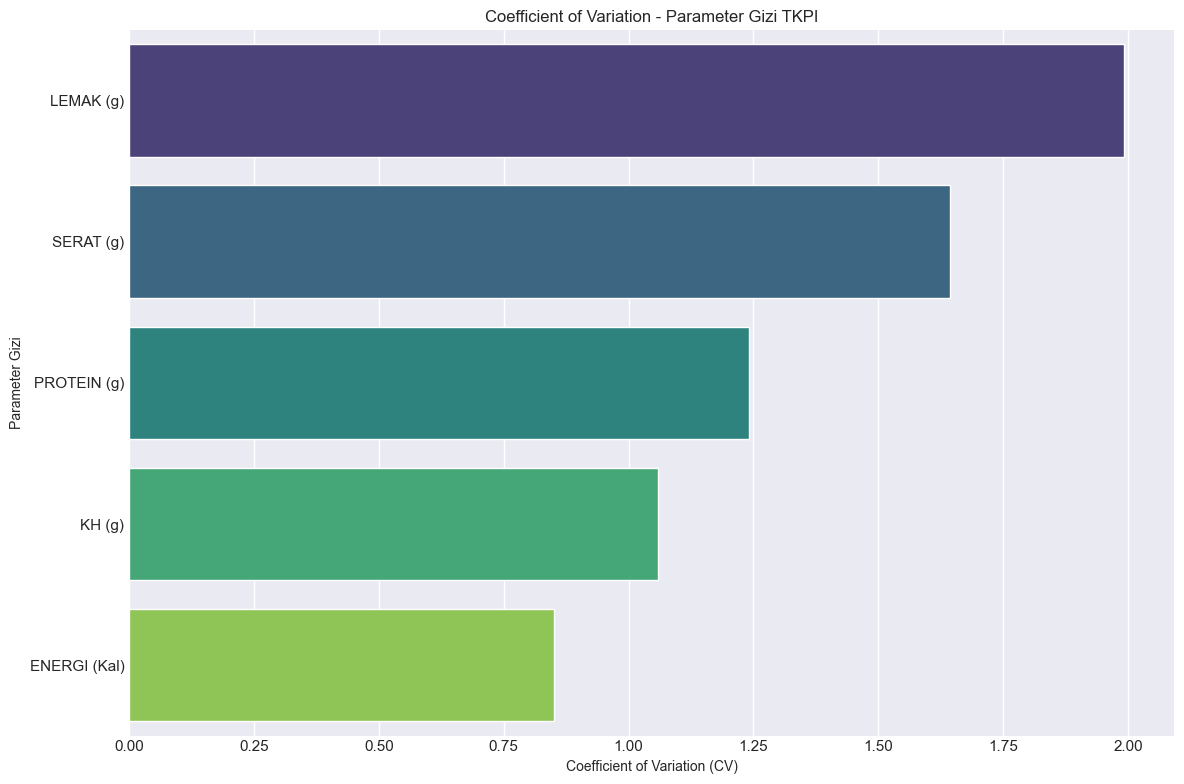

In [38]:
# Ambil semua kolom numerik dari TKPI (kecuali NAMA BAHAN dan SUMBER)
all_columns = df_tkpi_clean.columns.tolist()
exclude_cols = ['NAMA BAHAN', 'SUMBER']
numeric_cols = [col for col in all_columns if col not in exclude_cols]

print(f"\n[1] Total kolom numerik di TKPI: {len(numeric_cols)} kolom")
print(f"    Kolom yang akan dianalisis: {numeric_cols[:10]}...")

# Hitung statistik variasi untuk SEMUA kolom numerik
stats_df = df_tkpi_clean[numeric_cols].agg(['std', 'mean']).T
stats_df['cv'] = stats_df['std'] / stats_df['mean']  # coefficient of variation
stats_df = stats_df.sort_values('cv', ascending=False)

print("\nParameter dengan Variasi Tertinggi di TKPI (paling fleksibel untuk diatur):")
print(stats_df[['cv']].head(10).round(3))

# Mapping nama kolom 
kolom_mapping = {
    'Energi': 'ENERGI (Kal)',  
    'Protein': 'PROTEIN (g)',  
    'Lemak': 'LEMAK (g)',      
    'KH': 'KH (g)',            
    'Serat': 'SERAT (g)',      
}

# Cek kolom yang tersedia
available_params = []
for key, col in kolom_mapping.items():
    if col in df_tkpi_clean.columns:
        available_params.append(col)
    else:
        print(f"⚠️ Kolom '{col}' tidak ditemukan, cari alternatif...")
        # Cari kolom dengan nama mirip
        similar = [c for c in df_tkpi_clean.columns if key.upper() in c.upper()]
        if similar:
            print(f"   → Gunakan '{similar[0]}' sebagai pengganti")
            available_params.append(similar[0])

print(f"\nParameter yang tersedia untuk analisis: {available_params}")

# Prioritas berdasarkan literatur 
prioritas_list = [
    ('ENERGI', 5, 'Penentu berat badan'),
    ('PROTEIN', 5, 'Pertumbuhan dan kenyang'),
    ('KH', 4, 'Sumber energi utama'),
    ('LEMAK', 4, 'Densitas energi'),
    ('SERAT', 4, 'Kontrol berat badan')
]

print("\nRekomendasi Prioritas Parameter Gizi untuk Patokan:")
print("-" * 60)
for nama, score, alasan in prioritas_list:
    stars = '⭐' * score
    # Cari kolom yang sesuai
    matched_col = None
    for col in available_params:
        if nama in col.upper():
            matched_col = col
            break
    if matched_col:
        print(f"  {stars} {matched_col} (prioritas {score}/5) - {alasan}")
    else:
        print(f"  {stars} {nama} (prioritas {score}/5) - {alasan} [kolom tidak ditemukan]")

# Visualisasi CV parameter gizi (untuk yang valid)
if len(stats_df) > 0:
    plt.figure(figsize=(12, 8))
    top_n = min(15, len(stats_df))
    plot_data = stats_df.head(top_n)
    sns.barplot(x=plot_data['cv'].values, y=plot_data.index, palette='viridis')
    plt.title('Coefficient of Variation - Parameter Gizi TKPI', fontsize=12)
    plt.xlabel('Coefficient of Variation (CV)', fontsize=10)
    plt.ylabel('Parameter Gizi', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data untuk divisualisasikan")

### Solusi Problem 2 (Fitur Dominan): Variabel apa yang paling dominan mempengaruhi klasifikasi status gizi siswa?  


Feature Importance (pengaruh terhadap status gizi):
  1. Berat Badan: 0.6424 (64.2%)
  2. Tinggi Badan: 0.2770 (27.7%)
  3. Usia: 0.0777 (7.8%)
  4. Jenis Kelamin: 0.0029 (0.3%)


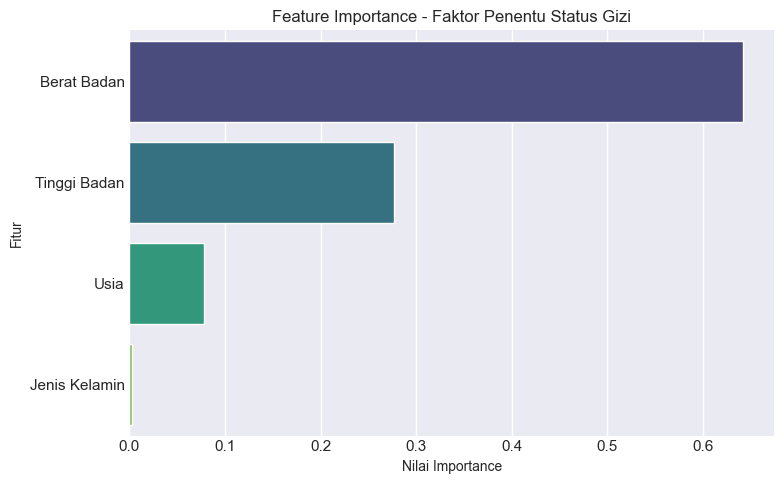


Pengaruh Jenis Kelamin terhadap Status Gizi:
Status_Gizi  Normal  Obesity  Overweight  Underweight
Gender                                               
Laki-laki      61.5      0.4        30.0          8.1
Perempuan      60.4      0.4        30.8          8.4


In [39]:
# Persiapan data untuk feature importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(df_bmi_clean['Status_Gizi'])

# Fitur yang digunakan
features = ['Age', 'Gender_Encoded', 'Height', 'Weight']
X = df_bmi_clean[features]

# Train Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X, y_encoded)

# Feature importance
importances = rf.feature_importances_
feature_names = ['Usia', 'Jenis Kelamin', 'Tinggi Badan', 'Berat Badan']

# Urutkan importance
indices = np.argsort(importances)[::-1]

print("\nFeature Importance (pengaruh terhadap status gizi):")
for i in range(len(feature_names)):
    print(f"  {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f} ({importances[indices[i]]*100:.1f}%)")

# Visualisasi
plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')
plt.title('Feature Importance - Faktor Penentu Status Gizi', fontsize=12)
plt.xlabel('Nilai Importance', fontsize=10)
plt.ylabel('Fitur', fontsize=10)
plt.tight_layout()
plt.show()

# Analisis pengaruh jenis kelamin
print("\nPengaruh Jenis Kelamin terhadap Status Gizi:")
gender_status = pd.crosstab(df_bmi_clean['Gender'], df_bmi_clean['Status_Gizi'], normalize='index') * 100
gender_status.index = gender_status.index.map({'P': 'Perempuan', 'L': 'Laki-laki'})
print(gender_status.round(1))

### Solusi Problem 3 (Distribusi dan Prevalensi): Bagaimana distribusi status gizi siswa? Berapa persentase siswa yang memerlukan intervensi gizi prioritas (underweight dan overweight)? Kelompok usia mana yang diprioritaskan?  


Distribusi Kategori BMI Siswa:
  - Underweight: 624 siswa (2.6%)
  - Normal: 23024 siswa (95.6%)
  - Overweight: 354 siswa (1.5%)
  - Obesity: 91 siswa (0.4%)

SISWA PRIORITAS INTERVENSI (Underweight + Overweight + Obesity): 1069 siswa (4.4%)

Kelompok Usia dengan Masalah Gizi Terbanyak (Berdasarkan BMI):
Age_Group
Q1 (6-7 thn)      585
Q3 (10-11 thn)    207
Q4 (12 thn)       179
Q2 (8-9 thn)       98
dtype: int64


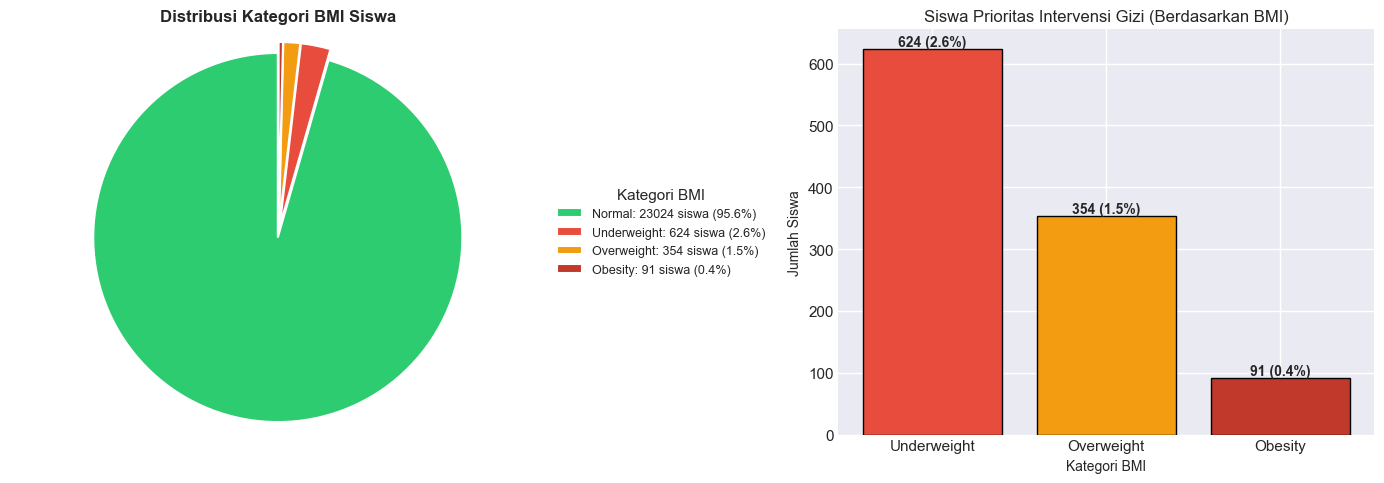


KESIMPULAN ANALISIS BMI

RINGKASAN:

   - Total siswa: 24093 siswa
   - Siswa dengan BMI Normal: 23024 siswa (95.6%)
   - Siswa PRIORITAS INTERVENSI: 1069 siswa (4.4%)
        • Underweight: 624 siswa
        • Overweight: 354 siswa
        • Obesity: 91 siswa

KELOMPOK USIA PRIORITAS:
   - Kelompok usia dengan masalah gizi terbanyak: Q1 (6-7 thn)
   - Distribusi masalah per kelompok usia:

        • Q1 (6-7 thn): 585 siswa
        • Q3 (10-11 thn): 207 siswa
        • Q4 (12 thn): 179 siswa
        • Q2 (8-9 thn): 98 siswa

REKOMENDASI INTERVENSI:
   1. Fokus intervensi pada kelompok usia Q1 (6-7 thn)
   2. Untuk siswa UNDERWEIGHT: Tingkatkan asupan energi dan protein
   3. Untuk siswa OVERWEIGHT/OBESITY: Tingkatkan serat, kurangi kalori dan lemak
   4. Untuk siswa NORMAL: Pertahankan pola makan seimbang



In [43]:
# Distribusi kategori BMI
bmi_kategori_counts = df_bmi_clean['BMI_Kategori'].value_counts()
bmi_kategori_pct = df_bmi_clean['BMI_Kategori'].value_counts(normalize=True) * 100

print("\nDistribusi Kategori BMI Siswa:")
for kategori in ['Underweight', 'Normal', 'Overweight', 'Obesity']:
    if kategori in bmi_kategori_counts:
        print(f"  - {kategori}: {bmi_kategori_counts[kategori]} siswa ({bmi_kategori_pct[kategori]:.1f}%)")
    else:
        print(f"  - {kategori}: 0 siswa (0.0%)")

# Intervensi prioritas (Underweight + Overweight + Obesity)
prioritas_count = bmi_kategori_counts.get('Underweight', 0) + bmi_kategori_counts.get('Overweight', 0) + bmi_kategori_counts.get('Obesity', 0)
prioritas_pct = (prioritas_count / len(df_bmi_clean)) * 100
print(f"\nSISWA PRIORITAS INTERVENSI (Underweight + Overweight + Obesity): {prioritas_count} siswa ({prioritas_pct:.1f}%)")

# Kelompok usia prioritas (berdasarkan BMI_Kategori, bukan Status_Gizi)
df_bmi_clean['Age_Group'] = pd.qcut(df_bmi_clean['Age'], q=4, labels=['Q1 (6-7 thn)', 'Q2 (8-9 thn)', 'Q3 (10-11 thn)', 'Q4 (12 thn)'])
age_priority = df_bmi_clean[df_bmi_clean['BMI_Kategori'] != 'Normal'].groupby('Age_Group').size()
print("\nKelompok Usia dengan Masalah Gizi Terbanyak (Berdasarkan BMI):")
print(age_priority.sort_values(ascending=False))

# VISUALISASI
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Pie chart kategori BMI (dengan legend, tanpa autopct di dalam)
colors_bmi_pie = {
    'Underweight': '#E74C3C',
    'Normal': '#2ECC71',
    'Overweight': '#F39C12',
    'Obesity': '#C0392B'
}

# Urutkan warna sesuai index
sorted_colors_pie = [colors_bmi_pie.get(cat, '#3498DB') for cat in bmi_kategori_counts.index]

# Buat pie chart
wedges, texts = axes[0].pie(
    bmi_kategori_counts.values,
    labels=None,
    colors=sorted_colors_pie,
    startangle=90,
    explode=[0.03] * len(bmi_kategori_counts),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

# Legend untuk pie chart
legend_labels = [f"{cat}: {bmi_kategori_counts[cat]} siswa ({bmi_kategori_pct[cat]:.1f}%)" 
                 for cat in bmi_kategori_counts.index]
axes[0].legend(wedges, legend_labels, title="Kategori BMI", 
               loc='center left', bbox_to_anchor=(1, 0.5),
               fontsize=9, title_fontsize=11)
axes[0].set_title('Distribusi Kategori BMI Siswa', fontsize=12, fontweight='bold')
axes[0].axis('equal')

# 2. Bar plot intervensi prioritas
priority_data = ['Underweight', 'Overweight', 'Obesity']
priority_counts = [bmi_kategori_counts.get(s, 0) for s in priority_data]
priority_colors = ['#E74C3C', '#F39C12', '#C0392B']
bars = axes[1].bar(priority_data, priority_counts, color=priority_colors, edgecolor='black')
axes[1].set_title('Siswa Prioritas Intervensi Gizi (Berdasarkan BMI)', fontsize=12)
axes[1].set_xlabel('Kategori BMI', fontsize=10)
axes[1].set_ylabel('Jumlah Siswa', fontsize=10)

# Tambahkan label jumlah di atas bar
for bar, count in zip(bars, priority_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 f'{count} ({count/len(df_bmi_clean)*100:.1f}%)', 
                 ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# KESIMPULAN
print("\n" + "="*60)
print("KESIMPULAN ANALISIS BMI")
print("="*60)

print(f"""
RINGKASAN:

   - Total siswa: {len(df_bmi_clean)} siswa
   - Siswa dengan BMI Normal: {bmi_kategori_counts.get('Normal', 0)} siswa ({bmi_kategori_pct.get('Normal', 0):.1f}%)
   - Siswa PRIORITAS INTERVENSI: {prioritas_count} siswa ({prioritas_pct:.1f}%)
        • Underweight: {bmi_kategori_counts.get('Underweight', 0)} siswa
        • Overweight: {bmi_kategori_counts.get('Overweight', 0)} siswa
        • Obesity: {bmi_kategori_counts.get('Obesity', 0)} siswa

KELOMPOK USIA PRIORITAS:
   - Kelompok usia dengan masalah gizi terbanyak: {age_priority.idxmax()}
   - Distribusi masalah per kelompok usia:
""")

for age_group, count in age_priority.sort_values(ascending=False).items():
    print(f"        • {age_group}: {count} siswa")

print(f"""
REKOMENDASI INTERVENSI:
   1. Fokus intervensi pada kelompok usia {age_priority.idxmax()}
   2. Untuk siswa UNDERWEIGHT: Tingkatkan asupan energi dan protein
   3. Untuk siswa OVERWEIGHT/OBESITY: Tingkatkan serat, kurangi kalori dan lemak
   4. Untuk siswa NORMAL: Pertahankan pola makan seimbang
""")

### Solusi Problem 4 (Rekomendasi Gizi): Berdasarkan data TKPI, bahan pangan apa saja yang memiliki kandungan gizi untuk menaikkan berat badan (kategori Underweight), mengoptimalkan berat badan (kategori normal), dan menurunkan berat badan (kategori Overweight)?  


Kolom yang tersedia: ['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'KH (g)', 'SERAT (g)', 'LEMAK (g)']
Total bahan pangan yang dianalisis: 908 bahan

REKOMENDASI UNTUK UNDERWEIGHT (Menaikkan Berat Badan)
   Prioritas: Energi Tinggi, Protein Tinggi
               NAMA BAHAN  ENERGI (Kal)  PROTEIN (g)  LEMAK (g)  KH (g)
              Minyak ikan           902          0.0      100.0     0.0
      Minyak kacang tanah           902          0.0      100.0     0.0
      Minyak kelapa sawit           884          0.0      100.0     0.0
            Minyak zaitun           884          0.0      100.0     0.0
           Minyak kedelai           883          0.0       99.9     0.0
             Minyak wijen           881          0.2       99.7     0.0
            Minyak kelapa           870          1.0       98.0     0.0
Lemak kerbau (lemak sapi)           818          1.5       90.0     0.0
                  Mentega           742          0.5       81.6     1.4
                 Margarin      

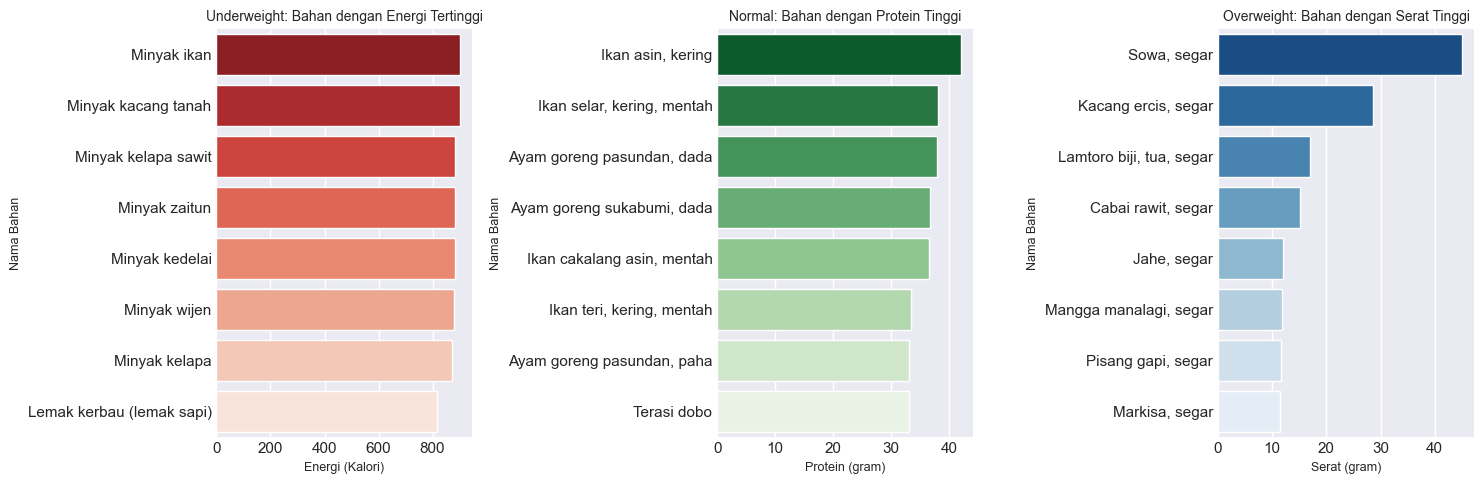

In [45]:
# Pastikan kolom yang diperlukan ada
required_cols = ['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'KH (g)', 'SERAT (g)', 'LEMAK (g)']
available_cols = [col for col in required_cols if col in df_tkpi_clean.columns]
print(f"\nKolom yang tersedia: {available_cols}")

# Filter bahan dengan nilai wajar (energi > 0)
df_tkpi_filtered = df_tkpi_clean[df_tkpi_clean['ENERGI (Kal)'] > 0].copy()
print(f"Total bahan pangan yang dianalisis: {len(df_tkpi_filtered)} bahan")

# --- UNTUK UNDERWEIGHT (Tinggi Energi + Protein) ---
print("\n" + "="*60)
print("REKOMENDASI UNTUK UNDERWEIGHT (Menaikkan Berat Badan)")
print("   Prioritas: Energi Tinggi, Protein Tinggi")
print("="*60)

underweight_foods = df_tkpi_filtered.nlargest(10, 'ENERGI (Kal)')[['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)']]
print(underweight_foods.to_string(index=False))

# --- UNTUK NORMAL (Seimbang) ---
print("\n" + "="*60)
print("REKOMENDASI UNTUK NORMAL (Mempertahankan Berat Badan Ideal)")
print("   Prioritas: Gizi Seimbang, Protein cukup")
print("="*60)

normal_foods = df_tkpi_filtered[
    (df_tkpi_filtered['ENERGI (Kal)'] >= 100) & 
    (df_tkpi_filtered['ENERGI (Kal)'] <= 250) &
    (df_tkpi_filtered['PROTEIN (g)'] >= 5)
].nlargest(10, 'PROTEIN (g)')[['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'KH (g)', 'SERAT (g)']]

if len(normal_foods) < 5:
    # Fallback: ambil bahan dengan protein tinggi tanpa filter energi
    normal_foods = df_tkpi_filtered.nlargest(10, 'PROTEIN (g)')[['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'KH (g)', 'SERAT (g)']]

print(normal_foods.to_string(index=False))

# --- UNTUK OVERWEIGHT (Tinggi Serat, Rendah Energi) ---
print("\n" + "="*60)
print("REKOMENDASI UNTUK OVERWEIGHT (Menurunkan Berat Badan)")
print("   Prioritas: Serat Tinggi, Energi Rendah")
print("="*60)

overweight_foods = df_tkpi_filtered[
    (df_tkpi_filtered['ENERGI (Kal)'] <= 150)
].nlargest(10, 'SERAT (g)')[['NAMA BAHAN', 'ENERGI (Kal)', 'SERAT (g)', 'PROTEIN (g)', 'KH (g)']]

if len(overweight_foods) < 5:
    # Fallback: ambil bahan dengan serat tertinggi
    overweight_foods = df_tkpi_filtered.nlargest(10, 'SERAT (g)')[['NAMA BAHAN', 'ENERGI (Kal)', 'SERAT (g)', 'PROTEIN (g)', 'KH (g)']]

print(overweight_foods.to_string(index=False))

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Underweight: Top energi
if len(underweight_foods) > 0:
    sns.barplot(data=underweight_foods.head(8), y='NAMA BAHAN', x='ENERGI (Kal)', ax=axes[0], palette='Reds_r')
    axes[0].set_title('Underweight: Bahan dengan Energi Tertinggi', fontsize=10)
    axes[0].set_xlabel('Energi (Kalori)', fontsize=9)
    axes[0].set_ylabel('Nama Bahan', fontsize=9)

# Normal: Top protein
if len(normal_foods) > 0:
    sns.barplot(data=normal_foods.head(8), y='NAMA BAHAN', x='PROTEIN (g)', ax=axes[1], palette='Greens_r')
    axes[1].set_title('Normal: Bahan dengan Protein Tinggi', fontsize=10)
    axes[1].set_xlabel('Protein (gram)', fontsize=9)
    axes[1].set_ylabel('Nama Bahan', fontsize=9)

# Overweight: Top serat
if len(overweight_foods) > 0:
    sns.barplot(data=overweight_foods.head(8), y='NAMA BAHAN', x='SERAT (g)', ax=axes[2], palette='Blues_r')
    axes[2].set_title('Overweight: Bahan dengan Serat Tinggi', fontsize=10)
    axes[2].set_xlabel('Serat (gram)', fontsize=9)
    axes[2].set_ylabel('Nama Bahan', fontsize=9)

plt.tight_layout()
plt.show()

### Solusi Problem 5 (Implementasi A/B Testing): Apakah perubahan parameter gizi (peningkatan protein dan serat, serta penyesuaian kalori) pada menu rekomendasi berpengaruh signifikan terhadap perbaikan status gizi siswa (peningkatan berat badan untuk Underweight, penurunan untuk Overweight, dan maintenance untuk Normal) dibandingkan dengan menu standar MBG?  

In [50]:
# Set seed untuk reproduktivitas
np.random.seed(42)

print("="*60)
print("A/B TESTING - MBG SMART PLATE")
print("Menu Standar (A) vs Menu Personalisasi (B)")
print("="*60)

# Parameter eksperimen
jumlah_siswa_per_grup = 500  # 500 siswa per grup
durasi_eksperimen = "3 bulan"

# Tingkat perbaikan status gizi yang diharapkan
# Underweight -> Normal, Overweight -> Normal, Normal -> tetap Normal
tingkat_perbaikan_A = 0.25  # Menu standar: 25% siswa membaik
tingkat_perbaikan_B = 0.32  # Menu personalisasi: 32% siswa membaik (target)

print(f"\nDesain Eksperimen:")
print(f"   - Grup A (Kontrol): Menu Standar MBG")
print(f"   - Grup B (Perlakuan): Menu Personalisasi MBG Smart Plate")
print(f"   - Jumlah siswa per grup: {jumlah_siswa_per_grup} siswa")
print(f"   - Durasi: {durasi_eksperimen}")

# Simulasi data perbaikan status gizi
perbaikan_A = np.random.binomial(n=1, p=tingkat_perbaikan_A, size=jumlah_siswa_per_grup).sum()
perbaikan_B = np.random.binomial(n=1, p=tingkat_perbaikan_B, size=jumlah_siswa_per_grup).sum()

# Hitung tingkat perbaikan
tingkat_perbaikan_A_observed = perbaikan_A / jumlah_siswa_per_grup
tingkat_perbaikan_B_observed = perbaikan_B / jumlah_siswa_per_grup

print(f"\nHasil Eksperimen:")
print(f"   - Grup A (Menu Standar): {perbaikan_A} dari {jumlah_siswa_per_grup} siswa membaik ({tingkat_perbaikan_A_observed*100:.1f}%)")
print(f"   - Grup B (Menu Personalisasi): {perbaikan_B} dari {jumlah_siswa_per_grup} siswa membaik ({tingkat_perbaikan_B_observed*100:.1f}%)")

A/B TESTING - MBG SMART PLATE
Menu Standar (A) vs Menu Personalisasi (B)

Desain Eksperimen:
   - Grup A (Kontrol): Menu Standar MBG
   - Grup B (Perlakuan): Menu Personalisasi MBG Smart Plate
   - Jumlah siswa per grup: 500 siswa
   - Durasi: 3 bulan

Hasil Eksperimen:
   - Grup A (Menu Standar): 131 dari 500 siswa membaik (26.2%)
   - Grup B (Menu Personalisasi): 142 dari 500 siswa membaik (28.4%)


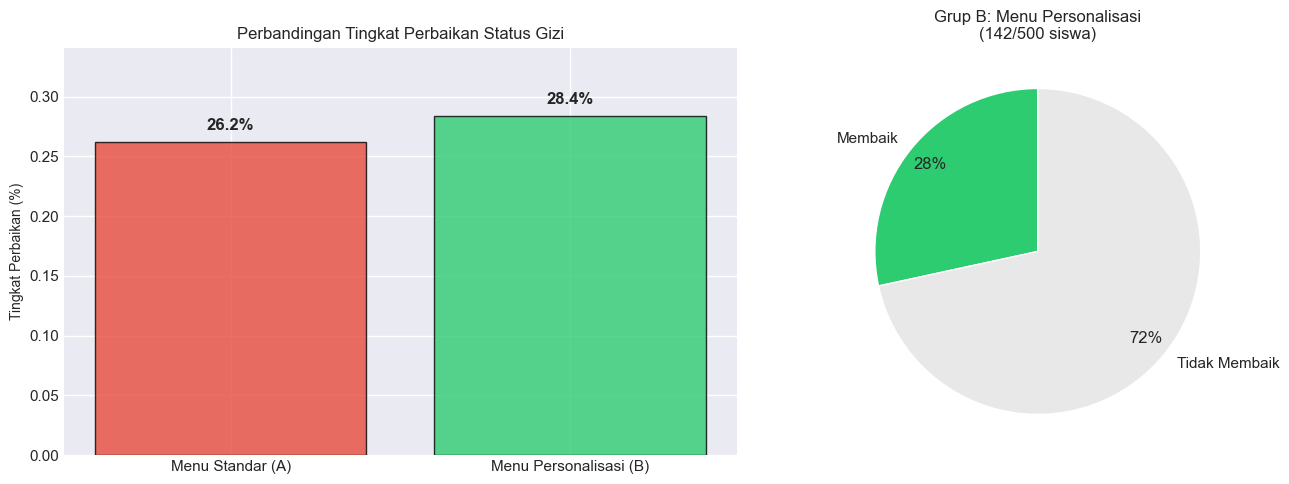

In [51]:
# Visualisasi perbandingan tingkat perbaikan
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart perbandingan
labels = ['Menu Standar (A)', 'Menu Personalisasi (B)']
rates = [tingkat_perbaikan_A_observed, tingkat_perbaikan_B_observed]
colors = ['#E74C3C', '#2ECC71']

bars = ax[0].bar(labels, rates, color=colors, edgecolor='black', alpha=0.8)
ax[0].set_title('Perbandingan Tingkat Perbaikan Status Gizi', fontsize=12)
ax[0].set_ylabel('Tingkat Perbaikan (%)', fontsize=10)
ax[0].set_ylim(0, max(rates) * 1.2)

for bar, rate in zip(bars, rates):
    ax[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
               f'{rate*100:.1f}%', ha='center', fontweight='bold')

# Donut chart untuk Grup B
sizes = [perbaikan_B, jumlah_siswa_per_grup - perbaikan_B]
colors_pie = ['#2ECC71', '#E8E8E8']
wedges, texts, autotexts = ax[1].pie(sizes, labels=['Membaik', 'Tidak Membaik'], 
                                      autopct='%1.0f%%', colors=colors_pie, 
                                      startangle=90, pctdistance=0.85)
ax[1].set_title(f'Grup B: Menu Personalisasi\n({perbaikan_B}/{jumlah_siswa_per_grup} siswa)', fontsize=12)

plt.tight_layout()
plt.show()

In [52]:
print("\n" + "="*60)
print("UJI STATISTIK Z-TEST UNTUK PROPORSI")
print("="*60)

# Hipotesis:
# H0: p_B <= p_A (menu personalisasi tidak lebih baik dari menu standar)
# H1: p_B > p_A (menu personalisasi LEBIH BAIK dari menu standar)

z_statistic, p_value = proportions_ztest(
    count=[perbaikan_A, perbaikan_B],
    nobs=[jumlah_siswa_per_grup, jumlah_siswa_per_grup],
    alternative='larger'  # one-tailed: menguji apakah B > A
)

print(f"\nHasil Uji Statistik:")
print(f"   Z-statistik: {z_statistic:.4f}")
print(f"   P-value: {p_value:.4f}")

# Tingkat signifikansi
alpha = 0.05
print(f"   Tingkat signifikansi (α): {alpha}")

# Interpretasi
print(f"\nINTERPRETASI:")
if p_value < alpha:
    print(f"   ✅ P-value ({p_value:.4f}) < α ({alpha})")
    print("   ✅ KEPUTUSAN: TOLAK H0")
    print("   ✅ KESIMPULAN: Menu personalisasi (B) SIGNIFIKAN lebih baik dari menu standar (A)")
    print("   ✅ REKOMENDASI: LUNCURKAN menu personalisasi ke seluruh sekolah!")
else:
    print(f"   ❌ P-value ({p_value:.4f}) > α ({alpha})")
    print("   ❌ KEPUTUSAN: GAGAL TOLAK H0")
    print("   ❌ KESIMPULAN: Tidak ada bukti cukup bahwa menu personalisasi lebih baik")
    print("   ❌ REKOMENDASI: LANJUTKAN EKSPERIMEN dengan sampel lebih besar atau revisi menu")


UJI STATISTIK Z-TEST UNTUK PROPORSI

Hasil Uji Statistik:
   Z-statistik: -0.7808
   P-value: 0.7825
   Tingkat signifikansi (α): 0.05

INTERPRETASI:
   ❌ P-value (0.7825) > α (0.05)
   ❌ KEPUTUSAN: GAGAL TOLAK H0
   ❌ KESIMPULAN: Tidak ada bukti cukup bahwa menu personalisasi lebih baik
   ❌ REKOMENDASI: LANJUTKAN EKSPERIMEN dengan sampel lebih besar atau revisi menu


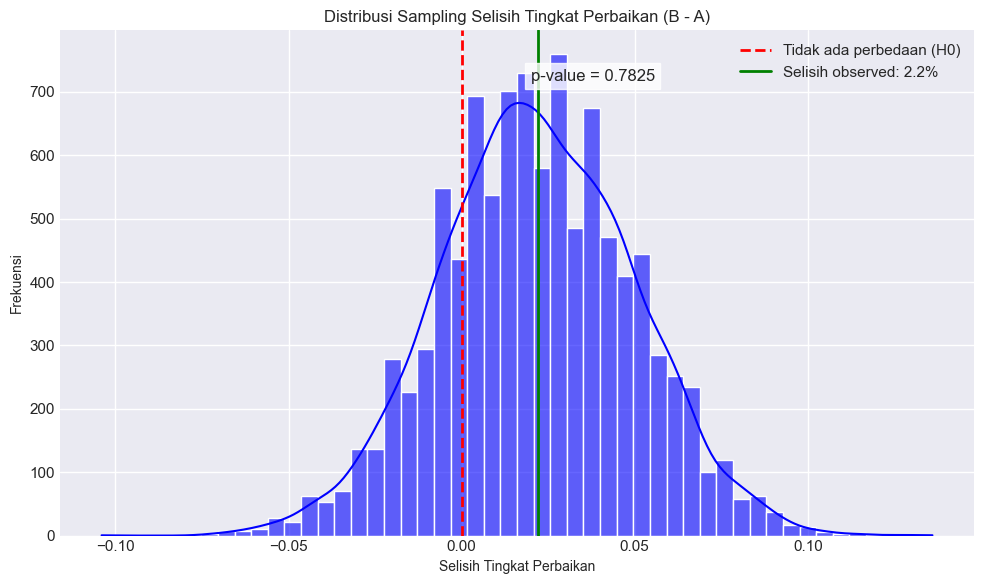

In [53]:
fig, ax = plt.subplots(figsize=(10, 6))

# Simulasi distribusi sampling untuk visualisasi
n_simulasi = 10000
simulasi_A = np.random.binomial(jumlah_siswa_per_grup, tingkat_perbaikan_A_observed, n_simulasi) / jumlah_siswa_per_grup
simulasi_B = np.random.binomial(jumlah_siswa_per_grup, tingkat_perbaikan_B_observed, n_simulasi) / jumlah_siswa_per_grup
diff_simulasi = simulasi_B - simulasi_A

# Plot distribusi selisih
sns.histplot(diff_simulasi, bins=50, kde=True, color='blue', alpha=0.6, ax=ax)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Tidak ada perbedaan (H0)')
ax.axvline(x=tingkat_perbaikan_B_observed - tingkat_perbaikan_A_observed, 
           color='green', linestyle='-', linewidth=2, 
           label=f'Selisih observed: {(tingkat_perbaikan_B_observed - tingkat_perbaikan_A_observed)*100:.1f}%')

ax.set_title('Distribusi Sampling Selisih Tingkat Perbaikan (B - A)', fontsize=12)
ax.set_xlabel('Selisih Tingkat Perbaikan', fontsize=10)
ax.set_ylabel('Frekuensi', fontsize=10)
ax.legend()

# Tambahkan anotasi p-value
ax.text(0.02, ax.get_ylim()[1]*0.9, f'p-value = {p_value:.4f}', 
        fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

**Insight Visualisasi dan Explanatory Data Analysis:**
- 

## Kesimpulan Akhir

- **Kesimpulan Problem 1:**
B

- **Kesimpulan Problem 2:**
B

- **Kesimpulan Problem 3:**
B

- **Kesimpulan Problem 4:**
B

- **Kesimpulan Problem 5:**
B